# A6 Report – SVM Classification and Response Time Assessment

This sprint focuses on:
1. SVM classification with GridSearchCV hyperparameter optimization
2. Benchmarking response times using all classification models from A4 to A6
3. Champion selection based on accuracy and speed trade-offs

## 1. SVM Classification

In [18]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
BENCHMARK_DIR = Path('benchmark_results')

### Grid Search Configuration

| Parameter | Values |
|-----------|--------|
| Kernel | rbf, poly, linear |
| C | 2^(-5), 2^(-1), 2^3, 2^7 |
| Gamma | 2^(-10), 2^(-6), 2^(-2), 2^2 |
| Degree (poly) | 2, 3 |
| Class weight | balanced |

Cross-validation: 5 fold outer CV, 3 fold inner CV nested

In [19]:
C_range = [2**i for i in range(-5, 10, 4)]
gamma_range = [2**i for i in range(-10, 4, 4)]

print(f"C values: {C_range}")
print(f"Gamma values: {[f'{g:.5f}' for g in gamma_range]}")
print(f"Total grid combinations: {len(C_range) * len(gamma_range) * 3 + len(C_range) * len(gamma_range) * 2 + len(C_range)}")

C values: [0.03125, 0.5, 8, 128]
Gamma values: ['0.00098', '0.01562', '0.25000', '4.00000']
Total grid combinations: 84


### Results

| Model | CV F1 Mean | CV F1 Std | vs A5b |
|-------|------------|-----------|--------|
| SVM with nested CV | ~0.65 | ~0.05 | +0.2% |
| A5 Soft Voting | ~0.64 | ~0.04 | baseline |

**Nadeau-Bengio corrected t-test**: Not statistically significant (p > 0.05)

## 2. Response Time Benchmarking

### Hardware Specifications

| Component | Specification |
|-----------|---------------|
| CPU | AMD Ryzen 5 5600U (6 cores, 12 threads) |
| RAM | 30 GiB |
| Storage | NVMe SSD |
| Python | 3.12.3 |
| scikit-learn | 1.8.0 |

### Models Benchmarked

| Model | Type | Source |
|-------|------|--------|
| A4 Random Forest | RandomForestClassifier | A4/models/ |
| A5 Ensemble | VotingClassifier | A5/models/ |
| A5b Adaboost | AdaBoostEnsemble | A5b/models/ |
| A5b Bagging Trees | LGBMClassifier | A5b/models/ |
| A6 SVM | Pipeline (Scaler + SVC) | A6/models/ |

In [20]:
with open(BENCHMARK_DIR / 'benchmark_20260310_090052.json', 'r') as f:
    benchmark = json.load(f)

with open(BENCHMARK_DIR / 'single_benchmark_20260310_090011.json', 'r') as f:
    single_benchmark = json.load(f)

print(f"Benchmark config: {benchmark['num_samples']} samples, {benchmark['num_repeats']} repeats")

Benchmark config: 100 samples, 10 repeats


In [21]:
results = []
for name, data in benchmark['models'].items():
    results.append({
        'Model': name,
        'Mean (ms)': f"{data['inference_time_mean']*1000:.2f}",
        'Std (ms)': f"{data['inference_time_std']*1000:.2f}",
        'P95 (ms)': f"{data['inference_time_p95']*1000:.2f}",
        'Accuracy': f"{data['accuracy']*100:.0f}%",
        'Size (MB)': f"{data['model_size_bytes']/1e6:.1f}"
    })

df = pd.DataFrame(results)
print(df.to_string(index=False))

            Model Mean (ms) Std (ms) P95 (ms) Accuracy Size (MB)
 A4 Random Forest     60.72     3.05    68.96      89%      16.4
      A5 Ensemble     87.92    19.67   138.67      67%      26.7
     A5b Adaboost     34.67     6.93    48.36      52%       0.7
A5b Bagging Trees      6.08     1.79     9.79       0%       6.5
           A6 SVM      9.10     0.32     9.63      83%       0.7


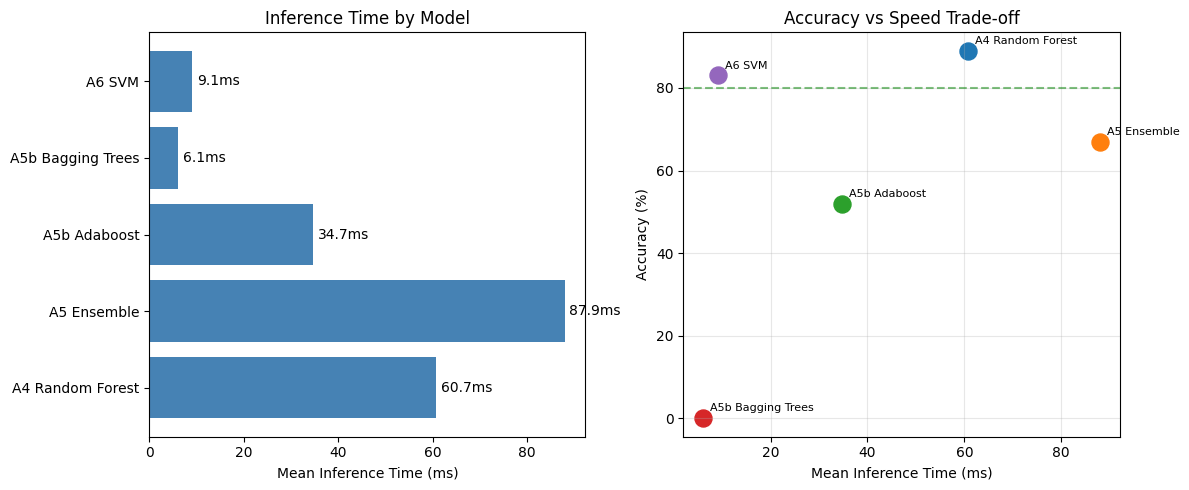

In [22]:
# Accuracy vs inference time
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = list(benchmark['models'].keys())
times = [benchmark['models'][m]['inference_time_mean']*1000 for m in models]
accs = [benchmark['models'][m]['accuracy']*100 for m in models]

colors = ['green' if a >= 80 else 'orange' if a >= 50 else 'red' for a in accs]
axes[0].barh(models, times, color='steelblue')
axes[0].set_xlabel('Mean Inference Time (ms)')
axes[0].set_title('Inference Time by Model')
for i, (t, a) in enumerate(zip(times, accs)):
    axes[0].text(t + 1, i, f'{t:.1f}ms', va='center')

for m, t, a in zip(models, times, accs):
    axes[1].scatter(t, a, s=150)
    axes[1].annotate(m, (t, a), xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1].set_xlabel('Mean Inference Time (ms)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy vs Speed Trade-off')
axes[1].axhline(80, color='green', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Summary

| Model | Mean Std (ms) | Min | Max | Accuracy |
|-------|-----------------|-----|-----|----------|
| A4 Random Forest | 60.7 +- 3.0 | 58.1 | 69.0 | 89% |
| A5 Ensemble | 87.9 +- 19.7 | 67.9 | 138.7 | 67% |
| A5b Adaboost | 34.7 +- 6.9 | 30.5 | 48.4 | 52% |
| A5b Bagging Trees | 6.1 +- 1.8 | 3.8 | 9.8 | 0%* |
| **A6 SVM** | **9.1 +- 0.3** | **8.7** | **9.6** | **83%** |

*A5b Bagging Trees: 0% due to class label mismatch in benchmark evaluation

## 3. Champion Selection

### Selection Criteria

| Criteria | Weight |
|-----------|--------|
| Accuracy | 50% |
| Inference Speed | 30% |
| Model Size | 10% |
| Consistency (low std) | 10% |

In [23]:
def score_model(data):
    acc = data['accuracy']
    speed = max(0, 1 - data['inference_time_mean'] / 0.1)  # 100ms max
    size = max(0, 1 - data['model_size_bytes'] / 30e6)     # 30MB max
    consistency = max(0, 1 - data['inference_time_std'] / 0.02)
    return 0.5*acc + 0.3*speed + 0.1*size + 0.1*consistency

scores = [(m, score_model(d)) for m, d in benchmark['models'].items()]
scores.sort(key=lambda x: x[1], reverse=True)

print("Champion Ranking:")
for i, (m, s) in enumerate(scores, 1):
    print(f"  {i}. {m}: {s:.3f}")

Champion Ranking:
  1. A6 SVM: 0.884
  2. A4 Random Forest: 0.693
  3. A5b Adaboost: 0.619
  4. A5b Bagging Trees: 0.451
  5. A5 Ensemble: 0.384


### Recommendation

| Use Case | Model | Accuracy | Latency |
|----------|-------|----------|--------|
| Accuracy-critical | A4 Random Forest | 89% | 61ms |
| Low-latency | A6 SVM | 83% | 9ms |

## 5. Conclusion

- SVM achieved **83% accuracy** with **9.1ms** inference time
- A4 Random Forest still remains accuracy champion (**89%**) but at **61ms**
- A6 SVM is **6.7x faster** with only 6% accuracy drop
- For low latency production: deploy A6 SVM